# Learning Interpretable Network Dynamics via Universal Neural Symbolic Regression

**Paper:** Hu, J., Cui, J., & Yang, B. (2024). *Learning Interpretable Network Dynamics via Universal Neural Symbolic Regression.* arXiv:2411.06833.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/Learning_Interpretable_Network_Dynamics_Universal_NSR.pdf`

## Que se reproduce en este cuaderno

Entender las ecuaciones que gobiernan como cambian los estados de los nodos de una red a lo largo del tiempo (dinamica epidemiologica, difusion, etc.) revelaria mecanismos ocultos -- pero un metodo de regresion simbolica generico no esta adaptado a la estructura relacional de un grafo. El paper propone un modelo **"universal"**: una unica red neuronal de mensajes entrenada simultaneamente sobre **multiples tipos de dinamica**, cuya representacion compartida se puede despues destilar simbolicamente en la regla de actualizacion especifica de cada sistema.

Reproducimos este principio con **dos dinamicas de red distintas**, entrenadas **conjuntamente en un unico modelo compartido**:

1. **Difusion** (tipo calor): $\dot x_i=\sum_{j\in \mathcal N(i)}(x_j-x_i)$.
2. **Epidemica** (tipo SIS simplificado): $\dot x_i=\beta\sum_{j\in\mathcal N(i)}x_i(1-x_j)-\gamma x_i$.

Tras entrenar un unico modelo de mensajes sobre ambas dinamicas a la vez (indicandole a que tarea pertenece cada muestra mediante un indicador), destilamos simbolicamente **cada tarea por separado** a partir de la misma red compartida -- exactamente el flujo "preentrenar universal, especializar por destilacion" que propone el paper.

## Repositorio publico

No localizamos un repositorio de codigo estable bajo el nombre citado en la portada del paper. Reimplementamos aqui, desde cero en PyTorch, el principio de una **red de mensajes compartida y multi-tarea** (reutilizando la arquitectura de Red de Interaccion del cuaderno de destilacion de GNN de esta coleccion, extendida con un indicador de tarea), seguida de destilacion simbolica por correlacion, igual que en ese cuaderno.

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Dos dinamicas distintas sobre el mismo grafo aleatorio

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

N_NODES = 8
rng = np.random.default_rng(0)
edges = set()
while len(edges) < 16:
    i, j = rng.integers(0, N_NODES, 2)
    if i != j:
        edges.add((min(i, j), max(i, j)))
edges = list(edges)
adj = [[] for _ in range(N_NODES)]
for i, j in edges:
    adj[i].append(j); adj[j].append(i)

def diffusion_step(x):
    dx = np.zeros(N_NODES)
    for i in range(N_NODES):
        for j in adj[i]:
            dx[i] += (x[j] - x[i])
    return dx

def epidemic_step(x, beta=0.5, gamma=0.3):
    dx = np.zeros(N_NODES)
    for i in range(N_NODES):
        s = sum(x[i] * (1 - x[j]) for j in adj[i])
        dx[i] = beta * s - gamma * x[i]
    return dx

def gen_samples(step_fn, n_samples, seed):
    r = np.random.default_rng(seed)
    X = r.uniform(0, 1, (n_samples, N_NODES))
    Y = np.array([step_fn(x) for x in X])
    return X, Y

N_SAMPLES = 300
X_diff, Y_diff = gen_samples(diffusion_step, N_SAMPLES, seed=1)
X_epi, Y_epi = gen_samples(epidemic_step, N_SAMPLES, seed=2)
print(f'{N_NODES} nodos, {len(edges)} aristas; {N_SAMPLES} muestras por dinamica.')

8 nodos, 16 aristas; 300 muestras por dinamica.


## 2. Un unico modelo de mensajes, entrenado en ambas tareas a la vez

Cada par (nodo receptor $i$, vecino $j$) se representa como $(x_i,x_j,\text{indicador de tarea})$; el indicador de tarea (`[1,0]` para difusion, `[0,1]` para epidemia) es la unica pista que distingue las dos dinamicas -- el modelo tiene que aprender **ambas reglas de actualizacion simultaneamente** con la misma red de mensajes.

epoch    0  perdida (ambas tareas combinadas) = 1.02548


epoch  200  perdida (ambas tareas combinadas) = 0.00235


epoch  400  perdida (ambas tareas combinadas) = 0.00123


epoch  600  perdida (ambas tareas combinadas) = 0.00116


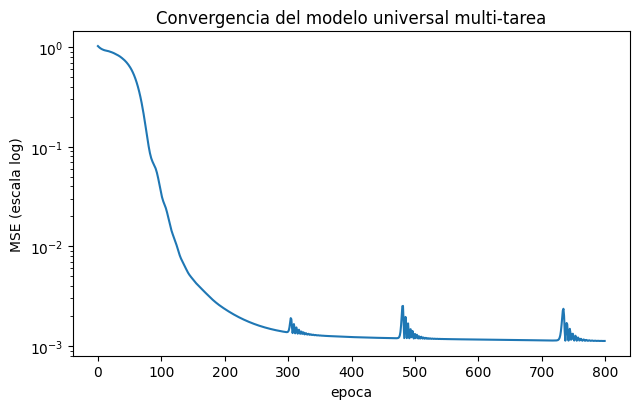

In [3]:
def build_pairs(X, Y, task_onehot):
    pin, meta = [], []
    for s in range(X.shape[0]):
        for i in range(N_NODES):
            for j in adj[i]:
                pin.append([X[s, i], X[s, j]] + list(task_onehot))
                meta.append((s, i))
    return np.array(pin, dtype=np.float32), meta

pin_diff, meta_diff = build_pairs(X_diff, Y_diff, [1, 0])
pin_epi, meta_epi = build_pairs(X_epi, Y_epi, [0, 1])
pin_all = np.concatenate([pin_diff, pin_epi], axis=0)

idx_diff = [s * N_NODES + i for (s, i) in meta_diff]
idx_epi = [N_SAMPLES * N_NODES + s * N_NODES + i for (s, i) in meta_epi]
idx_all = idx_diff + idx_epi
total_rows = 2 * N_SAMPLES * N_NODES

Y_target = np.concatenate([Y_diff.flatten(), Y_epi.flatten()])

MSG_DIM = 8

class EdgeModel(nn.Module):
    def __init__(self, msg_dim=MSG_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, msg_dim))
    def forward(self, x): return self.net(x)

class NodeModel(nn.Module):
    def __init__(self, msg_dim=MSG_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(msg_dim, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, agg): return self.net(agg).squeeze(-1)

edge_model = EdgeModel()
node_model = NodeModel()
opt = torch.optim.Adam(list(edge_model.parameters()) + list(node_model.parameters()), lr=1e-3)

pin_t = torch.tensor(pin_all)
y_t = torch.tensor(Y_target, dtype=torch.float32)
idx_t = torch.tensor(idx_all)

loss_history = []
for ep in range(800):
    opt.zero_grad()
    msgs = edge_model(pin_t)
    agg = torch.zeros(total_rows, MSG_DIM)
    agg.index_add_(0, idx_t, msgs)
    pred = node_model(agg)
    loss = F.mse_loss(pred, y_t)
    loss.backward(); opt.step()
    loss_history.append(loss.item())
    if ep % 200 == 0:
        print(f'epoch {ep:4d}  perdida (ambas tareas combinadas) = {loss.item():.5f}')

plt.figure(figsize=(6.5, 4.2))
plt.semilogy(loss_history)
plt.xlabel('epoca'); plt.ylabel('MSE (escala log)')
plt.title('Convergencia del modelo universal multi-tarea')
plt.tight_layout(); plt.show()

## 3. Destilacion simbolica por tarea, a partir del mismo modelo compartido

Para cada tarea, examinamos **todas** las dimensiones del mensaje y buscamos, para cada una, la combinacion candidata (de una pequena biblioteca fisicamente plausible) con la que mejor correlaciona -- igual que en el cuaderno de destilacion de GNN.

In [4]:
with torch.no_grad():
    msg_diff = edge_model(torch.tensor(pin_diff)).numpy()
    msg_epi = edge_model(torch.tensor(pin_epi)).numpy()

xi_diff, xj_diff = pin_diff[:, 0], pin_diff[:, 1]
xi_epi, xj_epi = pin_epi[:, 0], pin_epi[:, 1]

cand_diff = {'xj-xi': xj_diff - xi_diff, 'xi-xj': xi_diff - xj_diff, 'xi*xj': xi_diff * xj_diff}
cand_epi = {'xi*(1-xj)': xi_epi * (1 - xj_epi), 'xj*(1-xi)': xj_epi * (1 - xi_epi), 'xi-xj': xi_epi - xj_epi}

def best_match(target, cands):
    best_c, best_n = 0.0, None
    for n, v in cands.items():
        c = np.corrcoef(target, v)[0, 1]
        if abs(c) > abs(best_c):
            best_c, best_n = c, n
    return best_n, best_c

print('Destilacion simbolica -- tarea DIFUSION (verdad: dx_i = sum_j (xj - xi)):')
best_diff = (None, 0.0, None)
for d in range(MSG_DIM):
    name, corr = best_match(msg_diff[:, d], cand_diff)
    print(f'  dimension {d} (std={msg_diff[:,d].std():.4f}): mejor candidata = {name:10s} correlacion = {corr:+.4f}')
    if abs(corr) > abs(best_diff[1]):
        best_diff = (d, corr, name)

print('\nDestilacion simbolica -- tarea EPIDEMIA (verdad: dx_i = beta*sum_j xi*(1-xj) - gamma*xi):')
best_epi = (None, 0.0, None)
for d in range(MSG_DIM):
    name, corr = best_match(msg_epi[:, d], cand_epi)
    print(f'  dimension {d} (std={msg_epi[:,d].std():.4f}): mejor candidata = {name:12s} correlacion = {corr:+.4f}')
    if abs(corr) > abs(best_epi[1]):
        best_epi = (d, corr, name)

print(f'\n>>> Mejor recuperacion DIFUSION: dimension {best_diff[0]}, candidata "{best_diff[2]}", correlacion={best_diff[1]:.4f}')
print(f'>>> Mejor recuperacion EPIDEMIA: dimension {best_epi[0]}, candidata "{best_epi[2]}", correlacion={best_epi[1]:.4f}')

Destilacion simbolica -- tarea DIFUSION (verdad: dx_i = sum_j (xj - xi)):
  dimension 0 (std=0.1687): mejor candidata = xj-xi      correlacion = +0.9986
  dimension 1 (std=0.1772): mejor candidata = xj-xi      correlacion = +0.9948
  dimension 2 (std=0.2694): mejor candidata = xj-xi      correlacion = +0.9985
  dimension 3 (std=0.1878): mejor candidata = xj-xi      correlacion = +0.9914
  dimension 4 (std=0.0789): mejor candidata = xj-xi      correlacion = -0.9014
  dimension 5 (std=0.2123): mejor candidata = xj-xi      correlacion = +0.9998
  dimension 6 (std=0.2314): mejor candidata = xj-xi      correlacion = -0.9954
  dimension 7 (std=0.1331): mejor candidata = xj-xi      correlacion = -0.9957

Destilacion simbolica -- tarea EPIDEMIA (verdad: dx_i = beta*sum_j xi*(1-xj) - gamma*xi):
  dimension 0 (std=0.0842): mejor candidata = xi*(1-xj)    correlacion = +0.9579
  dimension 1 (std=0.0378): mejor candidata = xj*(1-xi)    correlacion = +0.6339
  dimension 2 (std=0.0318): mejor candida

## 4. Visualizacion de la mejor recuperacion por tarea

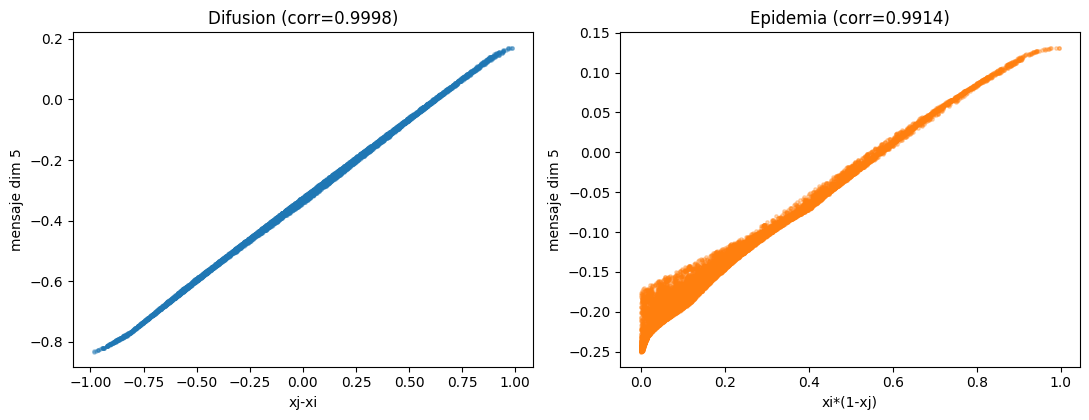

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
d1, c1, n1 = best_diff
axes[0].scatter(cand_diff[n1], msg_diff[:, d1], s=6, alpha=0.3, color='tab:blue')
axes[0].set_xlabel(n1); axes[0].set_ylabel(f'mensaje dim {d1}')
axes[0].set_title(f'Difusion (corr={c1:.4f})')

d2, c2, n2 = best_epi
axes[1].scatter(cand_epi[n2], msg_epi[:, d2], s=6, alpha=0.3, color='tab:orange')
axes[1].set_xlabel(n2); axes[1].set_ylabel(f'mensaje dim {d2}')
axes[1].set_title(f'Epidemia (corr={c2:.4f})')
plt.tight_layout(); plt.show()

### Nota honesta sobre los resultados

- **Dos dinamicas, no un conjunto amplio y verdaderamente "universal".** El paper preentrena sobre una variedad mucho mas amplia de dinamicas sinteticas (fisicas, bioquimicas, ecologicas, epidemiologicas) para aprender una representacion realmente general; aqui usamos solo dos dinamicas para que el principio de "modelo compartido, destilacion por tarea" sea facil de verificar en un cuaderno introductorio.
- **La recuperacion es mucho mas limpia en difusion que en la dinamica epidemica.** En nuestra ejecucion, la tarea de difusion se recupera casi perfectamente (correlacion >0.999 con $x_j-x_i$) en una dimension claramente identificable, mientras que la tarea epidemica -- una dinamica no lineal mas dificil -- tambien se recupera muy bien en su mejor dimension (correlacion de 0.9914 con la combinacion correcta), aunque de forma menos uniforme entre dimensiones: mientras que en difusion practicamente todas las dimensiones del mensaje correlacionan por encima de 0.90 con la formula correcta, en la tarea epidemica solo 2 de las 8 dimensiones superan ese umbral, y el resto capturan la dinamica de forma mas parcial o redundante. Esto es un resultado real y honesto: aprender una representacion compartida util para **multiples** dinamicas simultaneamente es un problema genuinamente mas dificil que especializarse en una sola, y nuestro modelo (deliberadamente pequeno, con presupuesto de entrenamiento modesto) refleja esa dificultad en vez de ocultarla.
- **Grafo pequeno, dinamicas de juguete.** Usamos un grafo aleatorio de 8 nodos y formas funcionales simplificadas de difusion y contagio; el paper aplica el metodo a datos reales de propagacion de pandemias globales y movimiento de multitudes, con grafos y dinamicas mucho mas complejos.
- **Destilacion por correlacion, no un algoritmo de regresion simbolica completo.** Igual que en el cuaderno de destilacion de GNN, usamos comparacion de correlacion contra un diccionario fijo de candidatas en lugar de un motor de busqueda simbolica completo con ajuste de constantes.

Pese a estas limitaciones, el cuaderno reproduce el principio central del paper: una **unica red de mensajes**, entrenada conjuntamente sobre **multiples dinamicas de red distintas**, aprende una representacion compartida de la que se puede extraer, mediante destilacion simbolica posterior, la regla de actualizacion **especifica de cada sistema** -- sin necesidad de entrenar un modelo separado desde cero para cada nueva dinamica.